# Indian Job Market Dataset Analysis (2024-2026)

In [154]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor, GradientBoostingRegressor, VotingRegressor, BaggingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [155]:
df = pd.read_csv("C:/Users/Sonali/Downloads/Indian_jobmarket_data/india_job_market_2024_2026.csv")
df
# Dropping irrelevant colums that does not contribute to salary prediction
df.drop(['Job_ID', 'Date_Posted', 'Openings', 'Applicants'], axis=1, inplace=True)
df

,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Company_Rating
0,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,"Kotlin, Java, REST APIs",M.Tech/M.E.,4.0
1,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.,4.0
2,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,"JIRA, Excel, Power BI",MCA,3.6
3,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,"Penetration Testing, Python, Ethical Hacking, ...",BCA,3.5
4,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,"Docker, REST APIs, AWS, PostgreSQL",MCA,3.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Backend Developer,BEL,PSU/Govt,Media & Entertainment,Jaipur,Tier 2,Fresher (0-1 yr),Full-Time,Hybrid,4.5,"PostgreSQL, Java, Django, MongoDB, Docker",B.Tech/B.E.,4.2
4996,React Developer,Google,MNC,Manufacturing,Remote,Remote,Fresher (0-1 yr),Full-Time,Remote,4.3,"TypeScript, React, JavaScript, Redux, Next.js",B.Tech/B.E.,4.0
4997,QA Engineer,BHEL,PSU/Govt,FinTech,Remote,Remote,Mid (3-6 yrs),Contract,Remote,10.5,"Python, API Testing, Manual Testing, JIRA",B.Tech/B.E.,3.1
4998,Frontend Developer,Byju's,Indian Unicorn,FinTech,Remote,Remote,Mid (3-6 yrs),Internship,On-Site,1.6,"Tailwind CSS, Figma, React, JavaScript, TypeSc...",BCA,3.9


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job_Title           5000 non-null   object 
 1   Company             5000 non-null   object 
 2   Company_Type        5000 non-null   object 
 3   Industry            5000 non-null   object 
 4   City                5000 non-null   object 
 5   Location_Tier       5000 non-null   object 
 6   Experience_Level    5000 non-null   object 
 7   Job_Type            5000 non-null   object 
 8   Work_Mode           5000 non-null   object 
 9   Salary_LPA          5000 non-null   float64
 10  Skills_Required     5000 non-null   object 
 11  Education_Required  5000 non-null   object 
 12  Company_Rating      5000 non-null   float64
dtypes: float64(2), object(11)
memory usage: 507.9+ KB


### Lets see unique values in all the columns

In [126]:
for col in df.columns:
    print(col, ':' ,df[col].unique())

Job_Title : ['Android Developer' 'QA Engineer' 'Business Analyst'
 'Cybersecurity Analyst' 'Python Developer' 'Backend Developer'
 'Power BI Developer' 'Java Developer' 'Technical Lead' 'UI/UX Designer'
 'Data Analyst' 'Software Engineer' 'Machine Learning Engineer'
 'Data Engineer' 'Node.js Developer' 'Computer Vision Engineer'
 'MLOps Engineer' 'DevOps Engineer' 'Product Manager' 'Frontend Developer'
 'Full Stack Developer' 'Cloud Engineer' 'React Developer'
 'Blockchain Developer' 'AI Engineer' 'Research Scientist' 'iOS Developer'
 'NLP Engineer' 'Data Scientist' 'Engineering Manager']
Company : ['Tech Mahindra' 'Dream11' 'HAL' 'Groww' 'Oracle' 'Nykaa' 'PhonePe'
 'Cisco' 'HCL Technologies' 'Chargebee' 'Infosys' 'Hasura' 'ISRO' 'Google'
 'BHEL' 'Cognizant' 'BrowserStack' 'Setu' 'BSNL' 'CRED' "Byju's"
 'Lenskart' 'Khatabook' 'Wipro' 'Razorpay' 'Deloitte' 'Accenture'
 'Urban Company' 'Zoho' 'Leadsquared' 'BEL' 'Flipkart' 'TCS' 'InMobi'
 'IBM' 'ONGC' 'Freshworks' 'MakeMyTrip' 'Ola' 'Cap

## Exploratory Data Analysis (EDA)

#### Experience wise Job Count

Text(0, 0.5, 'No.of jobs')

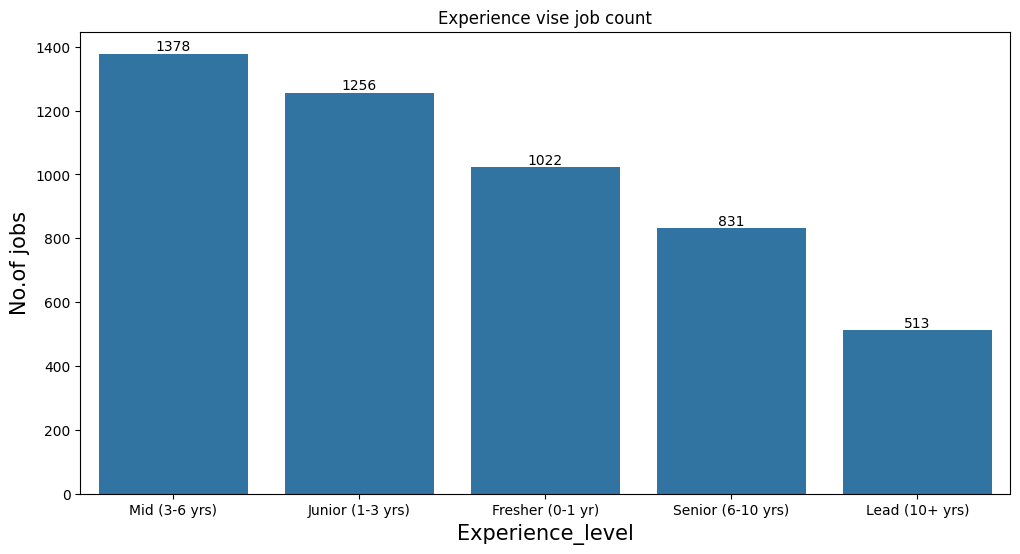

In [157]:
count = df['Experience_Level'].value_counts()
#df['Experience_Level']
count
plt.figure(figsize=(12,6))
bp = sns.barplot(x=count.index, y=count.values)
for c in bp.containers:
  bp.bar_label(c)

plt.title('Experience vise job count')
plt.xlabel('Experience_level', fontsize =15)
plt.ylabel('No.of jobs', fontsize=15)

#### Experience level wise Average Salary Distribution

In [158]:
avg_sal = df.groupby('Experience_Level')['Salary_LPA'].mean()
avg_sal

Experience_Level
Fresher (0-1 yr)      5.502544
Junior (1-3 yrs)      9.920382
Lead (10+ yrs)       52.952242
Mid (3-6 yrs)        18.496734
Senior (6-10 yrs)    34.188448
Name: Salary_LPA, dtype: float64

Text(0, 0.5, 'Average Salary')

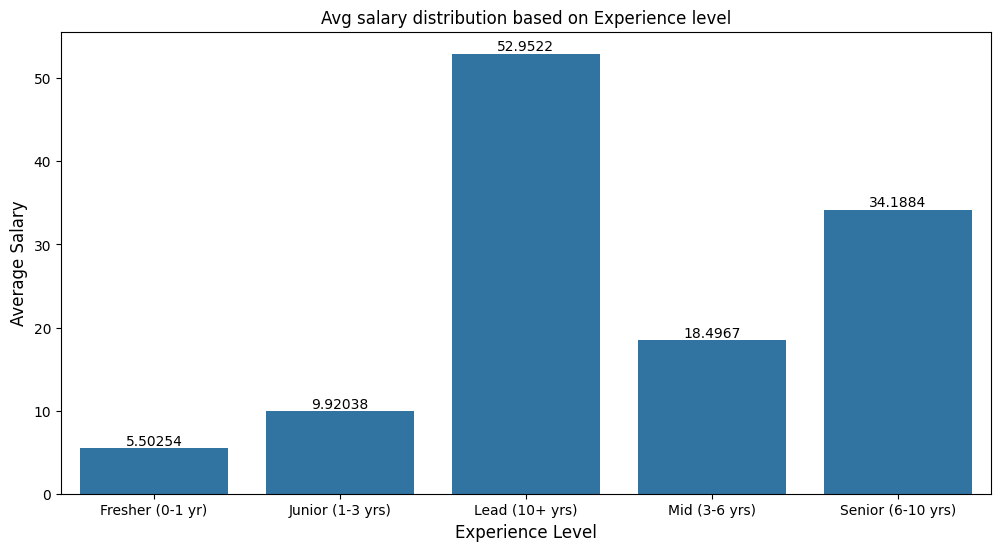

In [159]:
plt.figure(figsize =(12,6))
bp = sns.barplot(x = avg_sal.index, y = avg_sal.values)
for c in bp.containers:
    bp.bar_label(c)
plt.title("Avg salary distribution based on Experience level")
plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Average Salary", fontsize = 12)

#### Workmode distribution in percentage

In [160]:
wm_count = df['Work_Mode'].value_counts()
wm_count

Work_Mode
On-Site    2005
Hybrid     1728
Remote     1267
Name: count, dtype: int64

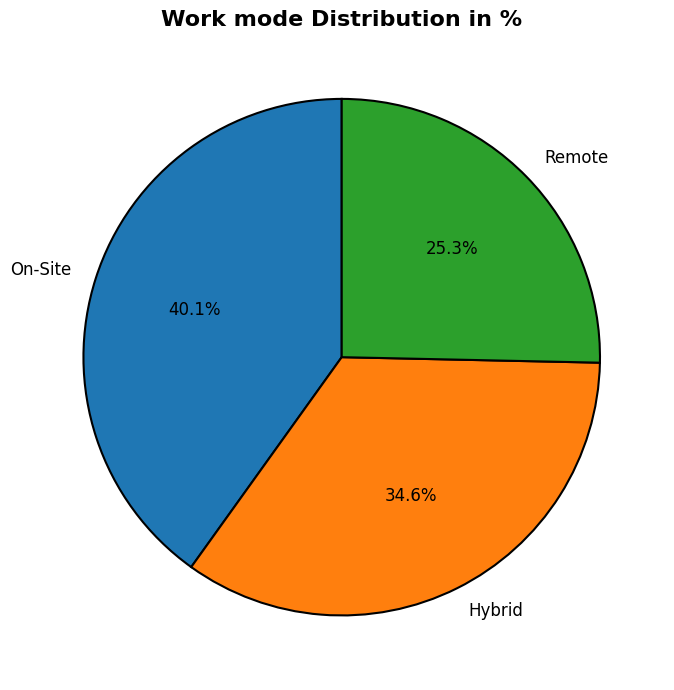

In [161]:
fig,ax = plt.subplots(figsize=(7,7))
wedges, texts, autotexts = ax.pie(wm_count.values,
                                  labels=wm_count.index,
                                  autopct="%1.1f%%",
                                  wedgeprops={'linewidth': 1.5, 'edgecolor': 'black'},
                                  textprops={'fontsize': 12},
                                  startangle = 90)
ax.set_title("Work mode Distribution in %", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Analysis of what Education qualification has the maximum weightage in Indian Job Market.
##### This will help to understand what education qualification will help the most to grab job opportunity in Indian Job Market.

In [162]:
edu_cnt = df['Education_Required'].value_counts()
edu_cnt

Education_Required
B.Tech/B.E.              2000
M.Tech/M.E.               927
MCA                       584
BCA                       509
B.Sc (CS/IT)              402
MBA                       308
B.Com + Certification     174
PhD                        96
Name: count, dtype: int64

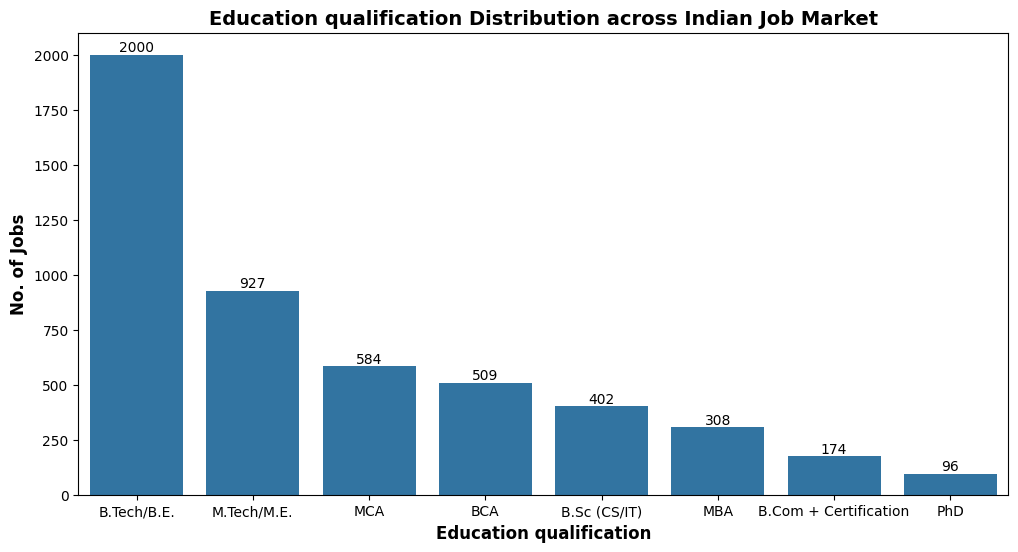

In [163]:
plt.figure(figsize=(12,6))
bp = sns.barplot(x= edu_cnt.index, y= edu_cnt.values)
for c in bp.containers:
    bp.bar_label(c)
plt.title("Education qualification Distribution across Indian Job Market", fontsize=14, fontweight='bold')
plt.xlabel("Education qualification", fontsize=12, fontweight='bold')
plt.ylabel("No. of Jobs", fontsize=12, fontweight='bold')
plt.show()

#### Highest paying Industry by Avg. Salary

In [164]:
avg_sal = df.groupby('Industry')['Salary_LPA'].mean()
avg_sal

Industry
Automobile                19.306522
Banking & Finance         20.848515
Consulting                18.473180
E-Commerce                19.270450
EdTech                    20.469077
FinTech                   18.875691
Gaming                    18.623973
Government/PSU            19.267822
HealthTech                17.291718
Information Technology    20.395534
Logistics                 24.434959
Manufacturing             20.695669
Media & Entertainment     18.552027
Retail                    22.284615
Telecom                   20.628947
Name: Salary_LPA, dtype: float64

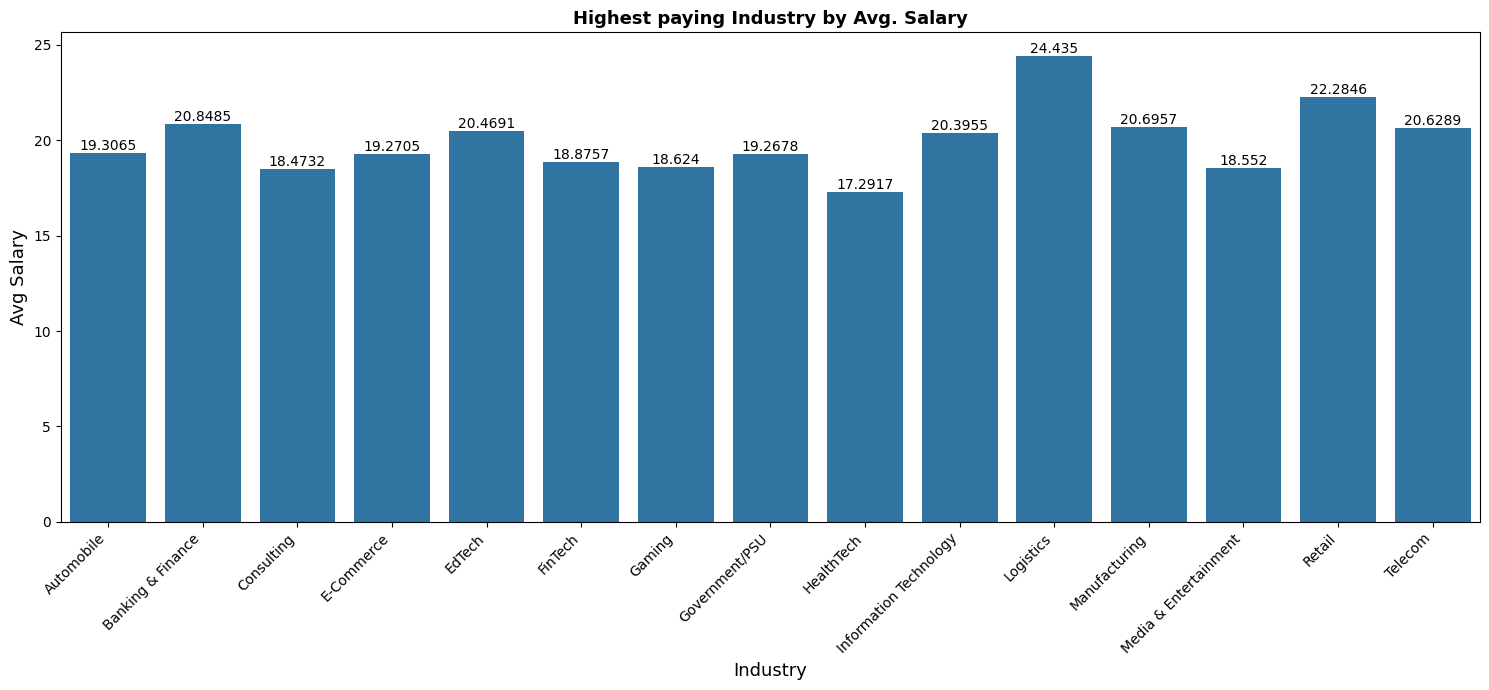

In [165]:
plt.figure(figsize=(15,7))
bp = sns.barplot(x= avg_sal.index, y= avg_sal.values)
for c in bp.containers:
    bp.bar_label(c)
plt.title("Highest paying Industry by Avg. Salary", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Industry', fontsize=13)
plt.ylabel('Avg Salary', fontsize=13)
plt.tight_layout()
plt.show()

#### Cities with Highest Job Opportunities

In [166]:
city = df['City'].value_counts()

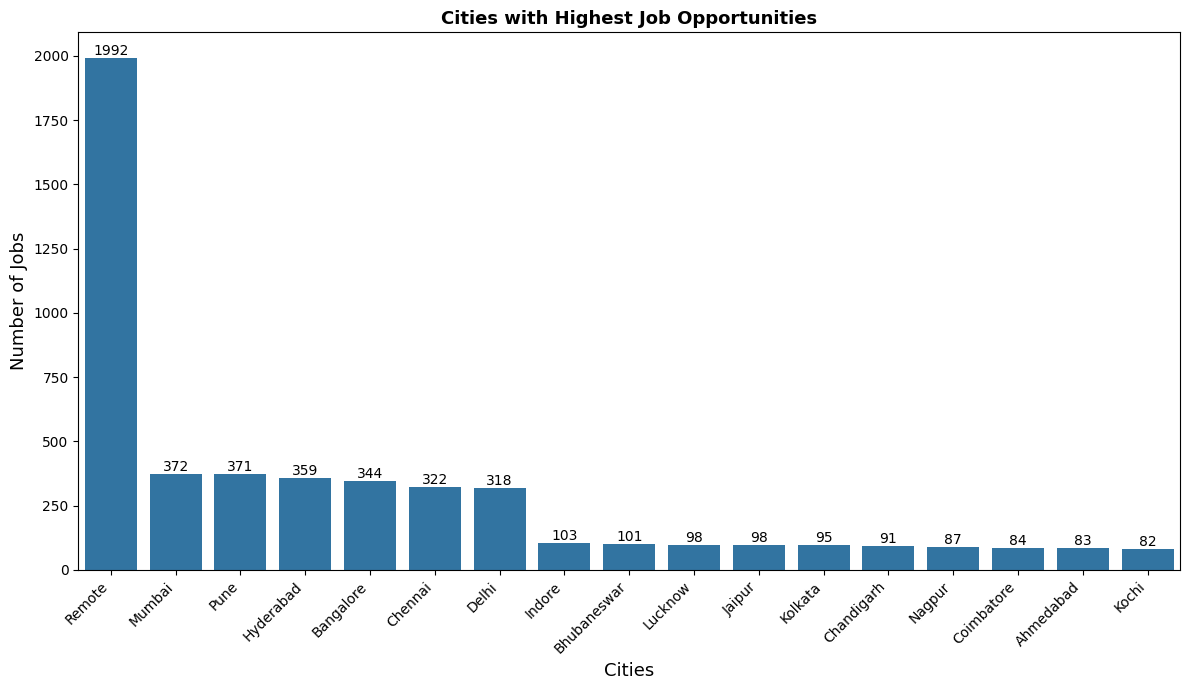

In [167]:
plt.figure(figsize=(12,7))
bp = sns.barplot(x= city.index, y= city.values)
for c in bp.containers:
    bp.bar_label(c)
plt.title("Cities with Highest Job Opportunities", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Cities', fontsize=13)
plt.ylabel('Number of Jobs', fontsize=13)
plt.tight_layout()
plt.show()

#### Top 10 most frequently posted Job Roles

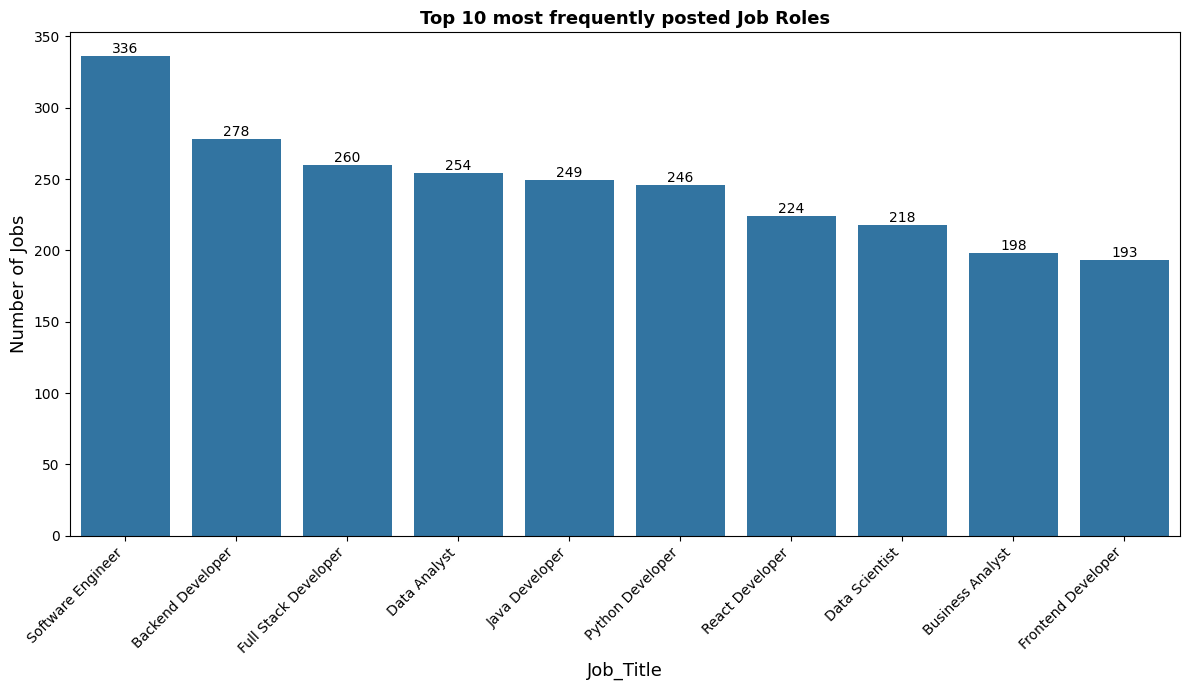

In [168]:
top_10_job_roles = df['Job_Title'].value_counts().head(10)
plt.figure(figsize=(12,7))
bp = sns.barplot(x= top_10_job_roles.index, y= top_10_job_roles.values)
for c in bp.containers:
    bp.bar_label(c)
plt.title("Top 10 most frequently posted Job Roles", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Job_Title', fontsize=13)
plt.ylabel('Number of Jobs', fontsize=13)
plt.tight_layout()
plt.show()

#### Company Type Contribution in job market

In [169]:
company_cnt = df['Company_Type'].value_counts()
company_cnt

Company_Type
MNC               1717
Startup           1430
Indian Unicorn    1210
PSU/Govt           643
Name: count, dtype: int64

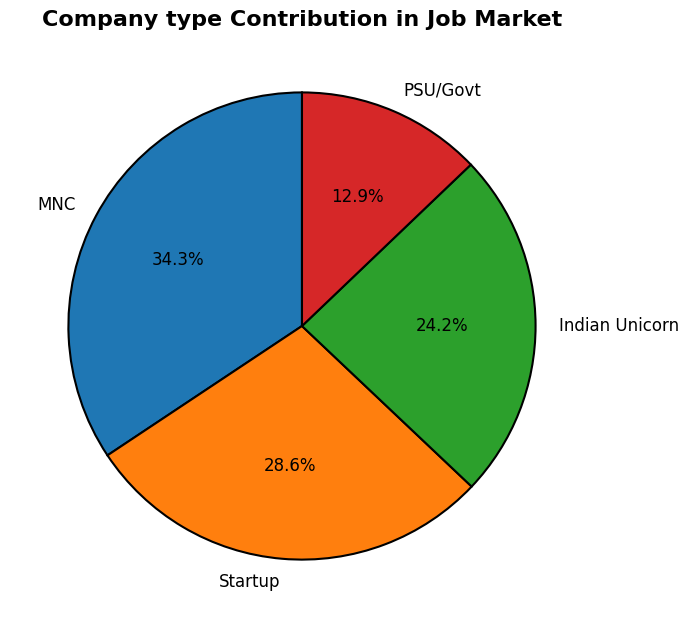

In [170]:
fig,ax = plt.subplots(figsize=(7,7))
wedges, texts, autotexts = ax.pie(company_cnt.values,
                                  labels=company_cnt.index,
                                  autopct="%1.1f%%",
                                  wedgeprops={'linewidth': 1.5, 'edgecolor': 'black'},
                                  textprops={'fontsize': 12},
                                  startangle = 90)
ax.set_title("Company type Contribution in Job Market", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Industry with maximum Job postings

In [171]:
ind_cnt = df['Industry'].value_counts()
ind_cnt

Industry
Information Technology    1545
FinTech                    543
E-Commerce                 511
Banking & Finance          404
EdTech                     401
HealthTech                 326
Consulting                 261
Manufacturing              254
Government/PSU             202
Media & Entertainment      148
Gaming                     146
Logistics                  123
Retail                      52
Automobile                  46
Telecom                     38
Name: count, dtype: int64

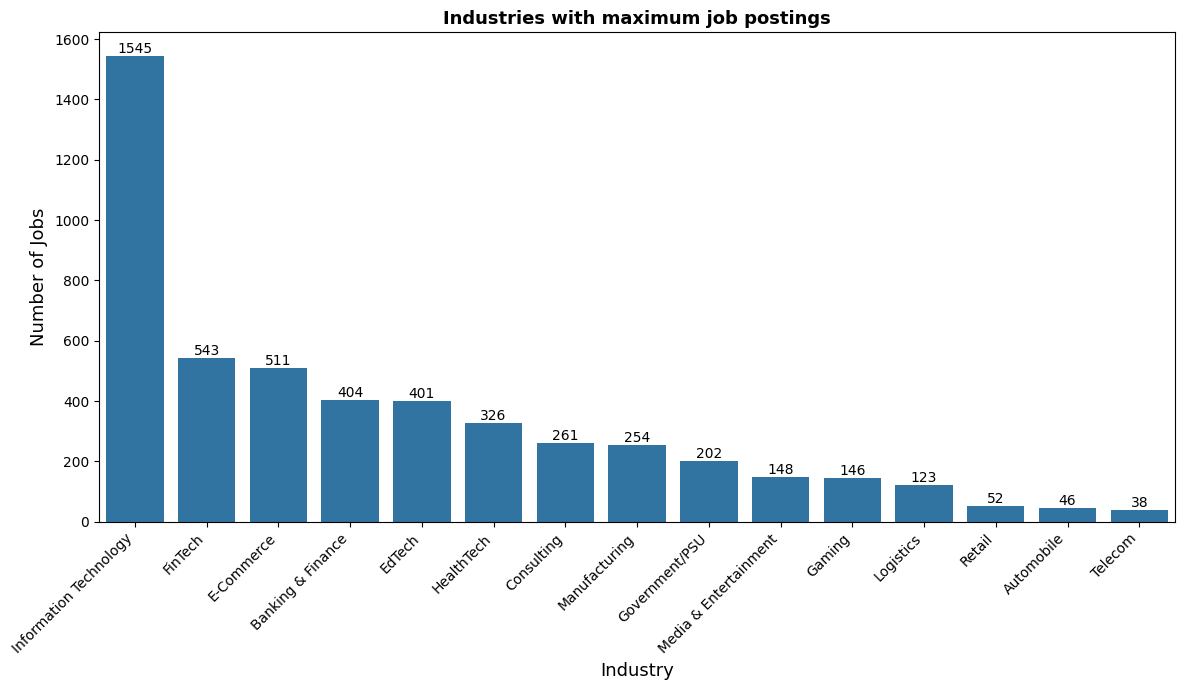

In [172]:
plt.figure(figsize=(12,7))
bp = sns.barplot(x= ind_cnt.index, y= ind_cnt.values)
for c in bp.containers:
    bp.bar_label(c)
plt.title("Industries with maximum job postings", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Industry', fontsize=13)
plt.ylabel('Number of Jobs', fontsize=13)
plt.tight_layout()
plt.show()

#### Since Skills_Required column has comma separated values, we cannot use label encoder to encode these values, instead, we use MultiLabelBinarizer (MLB).

In [127]:
df['Skills_Required']

0                                 Kotlin, Java, REST APIs
1       Selenium, Manual Testing, Postman, API Testing...
2                                   JIRA, Excel, Power BI
3       Penetration Testing, Python, Ethical Hacking, ...
4                      Docker, REST APIs, AWS, PostgreSQL
                              ...                        
4995            PostgreSQL, Java, Django, MongoDB, Docker
4996        TypeScript, React, JavaScript, Redux, Next.js
4997            Python, API Testing, Manual Testing, JIRA
4998    Tailwind CSS, Figma, React, JavaScript, TypeSc...
4999                                 ETL, Azure, Power BI
Name: Skills_Required, Length: 5000, dtype: object

In [128]:
df['Skills_Required'] = df['Skills_Required'].apply(lambda x: [s.strip() for s in x.split(',')])
df['Skills_Required']
mlb = MultiLabelBinarizer()
skill_col = mlb.fit_transform(df['Skills_Required'])
skill_col

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5000, 109))

In [130]:
mlb.classes_
df_skill = pd.DataFrame(skill_col, columns=mlb.classes_)
df_skill

,A/B Testing,API Testing,AWS,Adobe XD,Agile,Airflow,Algorithms,Android SDK,Ansible,Azure,...,Terraform,Transformers,TypeScript,User Research,Vector DBs,Web3.js,Wireframing,Xcode,YOLO,dbt
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4996,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4997,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4998,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [131]:
df = df.drop('Skills_Required', axis=1).join(df_skill)
df

,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,...,Terraform,Transformers,TypeScript,User Research,Vector DBs,Web3.js,Wireframing,Xcode,YOLO,dbt
0,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,...,0,0,0,0,0,0,0,0,0,0
1,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,...,0,0,0,0,0,0,0,0,0,0
2,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,...,0,0,0,0,0,0,0,0,0,0
3,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,...,0,0,0,0,0,0,0,0,0,0
4,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Backend Developer,BEL,PSU/Govt,Media & Entertainment,Jaipur,Tier 2,Fresher (0-1 yr),Full-Time,Hybrid,4.5,...,0,0,0,0,0,0,0,0,0,0
4996,React Developer,Google,MNC,Manufacturing,Remote,Remote,Fresher (0-1 yr),Full-Time,Remote,4.3,...,0,0,1,0,0,0,0,0,0,0
4997,QA Engineer,BHEL,PSU/Govt,FinTech,Remote,Remote,Mid (3-6 yrs),Contract,Remote,10.5,...,0,0,0,0,0,0,0,0,0,0
4998,Frontend Developer,Byju's,Indian Unicorn,FinTech,Remote,Remote,Mid (3-6 yrs),Internship,On-Site,1.6,...,0,0,1,0,0,0,0,0,0,0


#### Defining X and Y and splitting the data using train test split

In [132]:
X, y = df.drop('Salary_LPA', axis=1), df['Salary_LPA']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=26)

In [133]:
df.isnull().sum()
df.dtypes

Job_Title       object
Company         object
Company_Type    object
Industry        object
City            object
                 ...  
Web3.js          int64
Wireframing      int64
Xcode            int64
YOLO             int64
dbt              int64
Length: 121, dtype: object

#### One Hot Encoding

In [134]:
#cols_to_encode = ['Job_Title', 'Company', 'Company_Type', 'Industry', 'City', 'Location_Tier', 'Experience_Level', 'Job_Type', 'Work_Mode', 'Education_Required']
#le = LabelEncoder()
#for col in cols_to_encode:
    #df[col] = le.fit_transform(df[col])
#df
ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')
trnf = ColumnTransformer(transformers=[('OHE', ohe, ['Job_Title', 'Company', 'Company_Type', 'Industry', 'City', 'Location_Tier', 'Experience_Level', 'Job_Type', 'Work_Mode', 'Education_Required'])],
                                        remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')
X_trn_ohe = trnf.fit_transform(X_train)
X_tst_ohe = trnf.transform(X_test)

In [135]:
X_trn_ohe.info()
X_trn_ohe

<class 'pandas.core.frame.DataFrame'>
Index: 3500 entries, 3773 to 4917
Columns: 242 entries, Job_Title_Android Developer to dbt
dtypes: float64(133), int64(109)
memory usage: 6.5 MB


,Job_Title_Android Developer,Job_Title_Backend Developer,Job_Title_Blockchain Developer,Job_Title_Business Analyst,Job_Title_Cloud Engineer,Job_Title_Computer Vision Engineer,Job_Title_Cybersecurity Analyst,Job_Title_Data Analyst,Job_Title_Data Engineer,Job_Title_Data Scientist,...,Terraform,Transformers,TypeScript,User Research,Vector DBs,Web3.js,Wireframing,Xcode,YOLO,dbt
3773,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
1679,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4414,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1126,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1985,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1456,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


### Plotting barplot to highlight top 10 Skills 

In [136]:
skill_count = df_skill.sum()
top_10_skill = skill_count.sort_values(ascending=False).head(10)
top_10_skill.index, top_10_skill.values

(Index(['Python', 'REST APIs', 'AWS', 'SQL', 'Docker', 'Java', 'PostgreSQL',
        'React', 'TypeScript', 'Agile'],
       dtype='object'),
 array([1579,  998,  867,  847,  836,  636,  455,  454,  440,  429]))

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Python'),
  Text(1, 0, 'REST APIs'),
  Text(2, 0, 'AWS'),
  Text(3, 0, 'SQL'),
  Text(4, 0, 'Docker'),
  Text(5, 0, 'Java'),
  Text(6, 0, 'PostgreSQL'),
  Text(7, 0, 'React'),
  Text(8, 0, 'TypeScript'),
  Text(9, 0, 'Agile')])

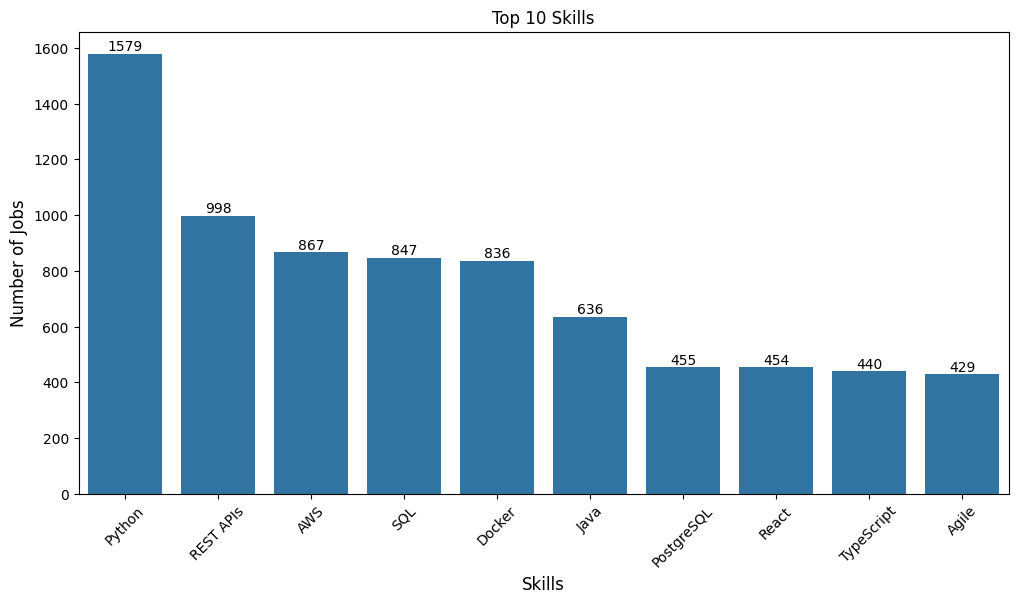

In [137]:
plt.figure(figsize=(12,6))
#plt.bar(top_10_skill.index, top_10_skill.values, edgecolor='black')
bp = sns.barplot(x = top_10_skill.index, y = top_10_skill.values)
for container in bp.containers:
    bp.bar_label(container)
plt.title('Top 10 Skills')
plt.xlabel('Skills', fontsize=12)
plt.ylabel('Number of Jobs', fontsize=12)
plt.xticks(rotation=45)

## Salary Prediction

In [139]:
scl = StandardScaler().set_output(transform='pandas')
X_trn_scl = scl.fit_transform(X_trn_ohe)
X_tst_scl = scl.transform(X_tst_ohe)

In [140]:
X_trn_scl

,Job_Title_Android Developer,Job_Title_Backend Developer,Job_Title_Blockchain Developer,Job_Title_Business Analyst,Job_Title_Cloud Engineer,Job_Title_Computer Vision Engineer,Job_Title_Cybersecurity Analyst,Job_Title_Data Analyst,Job_Title_Data Engineer,Job_Title_Data Scientist,...,Terraform,Transformers,TypeScript,User Research,Vector DBs,Web3.js,Wireframing,Xcode,YOLO,dbt
3773,-0.179287,-0.253285,-0.104768,-0.204124,-0.170614,-0.122806,-0.140761,-0.242242,-0.204124,-0.200297,...,-0.211604,-0.111528,-0.317221,-0.205638,-0.138635,-0.092981,-0.139701,-0.126353,-0.103365,-0.150976
2552,-0.179287,-0.253285,-0.104768,-0.204124,-0.170614,-0.122806,-0.140761,-0.242242,-0.204124,-0.200297,...,-0.211604,-0.111528,3.152380,-0.205638,-0.138635,-0.092981,-0.139701,-0.126353,-0.103365,-0.150976
1679,5.577642,-0.253285,-0.104768,-0.204124,-0.170614,-0.122806,-0.140761,-0.242242,-0.204124,-0.200297,...,-0.211604,-0.111528,-0.317221,-0.205638,-0.138635,-0.092981,-0.139701,-0.126353,-0.103365,-0.150976
3237,-0.179287,-0.253285,-0.104768,-0.204124,-0.170614,-0.122806,-0.140761,-0.242242,-0.204124,-0.200297,...,-0.211604,-0.111528,-0.317221,-0.205638,-0.138635,-0.092981,-0.139701,-0.126353,-0.103365,-0.150976
4414,-0.179287,-0.253285,-0.104768,-0.204124,-0.170614,-0.122806,-0.140761,-0.242242,-0.204124,-0.200297,...,-0.211604,-0.111528,-0.317221,-0.205638,7.213203,-0.092981,-0.139701,-0.126353,-0.103365,-0.150976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010,-0.179287,3.948123,-0.104768,-0.204124,-0.170614,-0.122806,-0.140761,-0.242242,-0.204124,-0.200297,...,-0.211604,-0.111528,-0.317221,-0.205638,-0.138635,-0.092981,-0.139701,-0.126353,-0.103365,-0.150976
1126,-0.179287,-0.253285,-0.104768,-0.204124,-0.170614,-0.122806,-0.140761,-0.242242,-0.204124,-0.200297,...,-0.211604,-0.111528,-0.317221,-0.205638,-0.138635,-0.092981,-0.139701,-0.126353,-0.103365,-0.150976
1985,-0.179287,-0.253285,-0.104768,-0.204124,-0.170614,-0.122806,-0.140761,-0.242242,-0.204124,-0.200297,...,-0.211604,-0.111528,-0.317221,-0.205638,-0.138635,-0.092981,-0.139701,-0.126353,-0.103365,-0.150976
1456,-0.179287,3.948123,-0.104768,-0.204124,-0.170614,-0.122806,-0.140761,-0.242242,-0.204124,-0.200297,...,-0.211604,-0.111528,-0.317221,-0.205638,-0.138635,-0.092981,-0.139701,-0.126353,-0.103365,-0.150976


In [141]:
lr = LinearRegression()
tree = DecisionTreeRegressor(random_state=26)
xgb = XGBRegressor(random_state=26)
gd = GradientBoostingRegressor(random_state=26)
rf = RandomForestRegressor(random_state=26)

In [142]:
models = [lr, tree, xgb, gd, rf]
score = []
for m in models:
    m.fit(X_trn_scl, y_train)
    y_pred = m.predict(X_tst_scl)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    score.append([m, rmse, r2, mae])
score

[[LinearRegression(),
  7.905603158321743,
  0.7952076706895825,
  5.3428262586763555],
 [DecisionTreeRegressor(random_state=26),
  6.25460896726033,
  0.8718129975790485,
  3.8098666666666663],
 [XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...),
  5.07275270871911,
  0.91567991

In [144]:
scores = pd.DataFrame(score, columns= ['model', 'rmse', 'r2score', 'mae'])
scores.sort_values('rmse')

,model,rmse,r2score,mae
4,"(DecisionTreeRegressor(max_features=1.0, rando...",4.762340,0.925684,2.871752
3,([DecisionTreeRegressor(criterion='friedman_ms...,5.034859,0.916935,3.185343
2,"XGBRegressor(base_score=None, booster=None, ca...",5.072753,0.915680,3.162801
1,DecisionTreeRegressor(random_state=26),6.254609,0.871813,3.809867
0,LinearRegression(),7.905603,0.795208,5.342826


### Other ensemble models

### Voting

In [145]:
lr = LinearRegression()
tree = DecisionTreeRegressor(random_state=26)
xgb = XGBRegressor(random_state=26)
gd = GradientBoostingRegressor(random_state=26)
rf = RandomForestRegressor(random_state=26)

In [146]:
voting = VotingRegressor(estimators=[('LR', lr),('DTree', tree),('XGB', xgb),('GD', gd),('RF', rf)], weights=[0, 1, 4, 1, 4])
voting.fit(X_trn_scl, y_train)
y_pred = voting.predict(X_tst_scl)
print("rmse =", root_mean_squared_error(y_test, y_pred))
print("r2_score =", r2_score(y_test, y_pred))

rmse = 4.75198400936753
r2_score = 0.9260064938411885


### Bagging

In [147]:
lr = LinearRegression()
tree = DecisionTreeRegressor(random_state=26)
xgb = XGBRegressor(random_state=26)
gd = GradientBoostingRegressor(random_state=26)
rf = RandomForestRegressor(random_state=26)

In [148]:
models = [lr, tree, xgb, gd, rf]
score = []
for m in models:
    bag = BaggingRegressor(random_state=26, estimator=m)
    bag.fit(X_trn_scl, y_train)
    y_pred = bag.predict(X_tst_scl)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    score.append([m, rmse, r2, mae])
scores = pd.DataFrame(score, columns= ['model', 'rmse', 'r2score', 'mae'])
scores.sort_values('rmse')

,model,rmse,r2score,mae
4,RandomForestRegressor(random_state=26),4.698493,0.927663,2.821021
2,"XGBRegressor(base_score=None, booster=None, ca...",4.735932,0.926506,2.933024
1,DecisionTreeRegressor(random_state=26),4.932472,0.920279,2.956993
3,GradientBoostingRegressor(random_state=26),5.058076,0.916167,3.256305
0,LinearRegression(),7.906166,0.795179,5.369305


### Stacking

In [150]:
lr = LinearRegression()
tree = DecisionTreeRegressor(random_state=26)
xgb = XGBRegressor(random_state=26)
gd = GradientBoostingRegressor(random_state=26)
rf = RandomForestRegressor(random_state=26)

In [153]:
stack = StackingRegressor(estimators=[('LR', lr),('TREE', tree),('GD',gd), ('RF', rf)],
                          final_estimator=xgb, passthrough=True)
stack.fit(X_trn_scl, y_train)
y_pred = stack.predict(X_tst_scl)
print("rmse =", root_mean_squared_error(y_test, y_pred))
print("r2_score =", r2_score(y_test, y_pred))
print("mae =", mean_absolute_error(y_test, y_pred))

rmse = 5.336436747273368
r2_score = 0.9066860877695438
mae = 3.1051265061338738


### Hyperparameter Tuning (RandomForest)

In [152]:
params = {'n_estimators': [50, 100, 150, 200,500], 'max_depth': [None,8,10,10,30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4],
         'max_features': ['sqrt', 'log2', None]}
kfold = KFold(n_splits=5, shuffle=True, random_state=26)
rf = RandomForestRegressor(random_state=26)
grid = GridSearchCV(rf, param_grid=params, cv=kfold, scoring='r2')
grid.fit(X_trn_scl, y_train)
grid.best_params_, grid.best_score_

({'max_depth': 8,
  'max_features': None,
  'min_samples_leaf': 1,
  'min_samples_split': 10,
  'n_estimators': 200},
 np.float64(0.9383672669622671))